
# Glucose Level Prediction Project

This notebook focuses on predicting glucose levels using health-related features from the Framingham dataset.
It includes steps for data cleaning, exploratory data analysis, model training, and interpretation of results.



## What To Do

1. Import and explore the `framingham.csv` dataset.
2. Clean the data (handle nulls, correct formats, etc.).
3. Visualize the distribution of glucose and related health indicators.
4. Perform feature selection and engineering.
5. Train ML models (e.g., Logistic Regression, Decision Tree, Random Forest).
6. Evaluate models using classification metrics.
7. Predict glucose levels and draw insights.
8. Visualize the model’s important features and performance.



# Glucose Level Prediction Project


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/SKILL FIELD/framingham.csv')
print(df.head())

   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   

   TenYearCHD  
0           0  
1           0  
2 

In [ ]:
# Display the count of missing values for each column
df.isnull().sum()

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


### Handling Missing Values: Imputation

In [ ]:
# Impute numerical columns with their median values
for col in ['cigsPerDay', 'BPMeds', 'totChol', 'BMI', 'heartRate', 'glucose']:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

# Impute 'education' with its mode
if df['education'].isnull().any():
    mode_val = df['education'].mode()[0]
    df['education'] = df['education'].fillna(mode_val)


### Data Type Conversion: Categorical Features

In [ ]:
# Convert appropriate columns to 'category' data type
for col in ['male', 'currentSmoker', 'prevalentStroke', 'prevalentHyp', 'diabetes']:
    df[col] = df[col].astype('category')

# Display the DataFrame's info to confirm data type changes
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   male             4240 non-null   category
 1   age              4240 non-null   int64   
 2   education        4240 non-null   float64 
 3   currentSmoker    4240 non-null   category
 4   cigsPerDay       4240 non-null   float64 
 5   BPMeds           4240 non-null   float64 
 6   prevalentStroke  4240 non-null   category
 7   prevalentHyp     4240 non-null   category
 8   diabetes         4240 non-null   category
 9   totChol          4240 non-null   float64 
 10  sysBP            4240 non-null   float64 
 11  diaBP            4240 non-null   float64 
 12  BMI              4240 non-null   float64 
 13  heartRate        4240 non-null   float64 
 14  glucose          4240 non-null   float64 
 15  TenYearCHD       4240 non-null   int64   
dtypes: category(5), float64(9), int64(2)
memor

None

In [ ]:
# Convert categorical categories into numeric dummy columns (0 or 1)
df_encoded = pd.get_dummies(df, columns=['male', 'currentSmoker', 'prevalentStroke', 'prevalentHyp', 'diabetes'], drop_first=True)

# Display the new columns to confirm
print(df_encoded.head())

   age  education  cigsPerDay  BPMeds  totChol  sysBP  diaBP    BMI  \
0   39        4.0         0.0     0.0    195.0  106.0   70.0  26.97   
1   46        2.0         0.0     0.0    250.0  121.0   81.0  28.73   
2   48        1.0        20.0     0.0    245.0  127.5   80.0  25.34   
3   61        3.0        30.0     0.0    225.0  150.0   95.0  28.58   
4   46        3.0        23.0     0.0    285.0  130.0   84.0  23.10   

   heartRate  glucose  TenYearCHD  male_1  currentSmoker_1  prevalentStroke_1  \
0       80.0     77.0           0    True            False              False   
1       95.0     76.0           0   False            False              False   
2       75.0     70.0           0    True             True              False   
3       65.0    103.0           1   False             True              False   
4       85.0     85.0           0   False             True              False   

   prevalentHyp_1  diabetes_1  
0           False       False  
1           False     

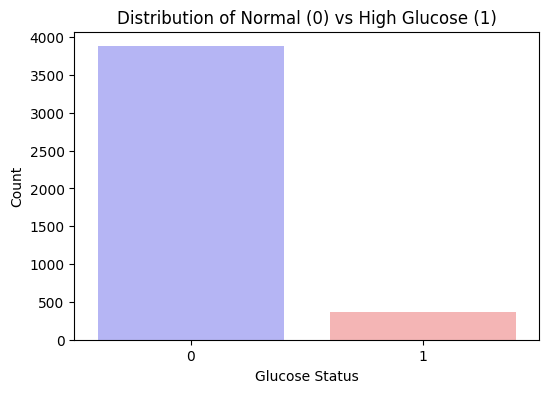

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the binary target first to visualize it
df_encoded['High_Glucose'] = (df_encoded['glucose'] >= 100).astype(int)

# Plot the distribution of the new classification target
plt.figure(figsize=(6, 4))
sns.countplot(x='High_Glucose', data=df_encoded, palette='bwr', hue='High_Glucose', legend=False)
plt.title('Distribution of Normal (0) vs High Glucose (1)')
plt.xlabel('Glucose Status')
plt.ylabel('Count')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Separate features (X) and our new classification target (y)
X_class = df_encoded.drop(columns=['glucose', 'High_Glucose'])
y_class = df_encoded['High_Glucose']

# 2. Split the data into 80% training and 20% testing
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

print(f"Classification Training shape: {X_train_c.shape}")
print(f"Classification Testing shape: {X_test_c.shape}")

Classification Training shape: (3392, 15)
Classification Testing shape: (848, 15)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train_c)
y_pred_log = log_reg.predict(X_test_scaled)
print("--- Logistic Regression Performance ---")
print(f"Accuracy: {accuracy_score(y_test_c, y_pred_log):.2f}")
print(classification_report(y_test_c, y_pred_log))
rf_class = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)
rf_class.fit(X_train_c, y_train_c)
y_pred_rf_c = rf_class.predict(X_test_c)

print("\n--- Random Forest Classifier Performance  ---")
print(f"Accuracy: {accuracy_score(y_test_c, y_pred_rf_c):.2f}")
print(classification_report(y_test_c, y_pred_rf_c))

--- Logistic Regression Performance ---
Accuracy: 0.77
              precision    recall  f1-score   support

           0       0.94      0.80      0.86       774
           1       0.17      0.45      0.25        74

    accuracy                           0.77       848
   macro avg       0.56      0.62      0.55       848
weighted avg       0.87      0.77      0.81       848


--- Random Forest Classifier Performance  ---
Accuracy: 0.92
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       774
           1       0.75      0.16      0.27        74

    accuracy                           0.92       848
   macro avg       0.84      0.58      0.61       848
weighted avg       0.91      0.92      0.90       848



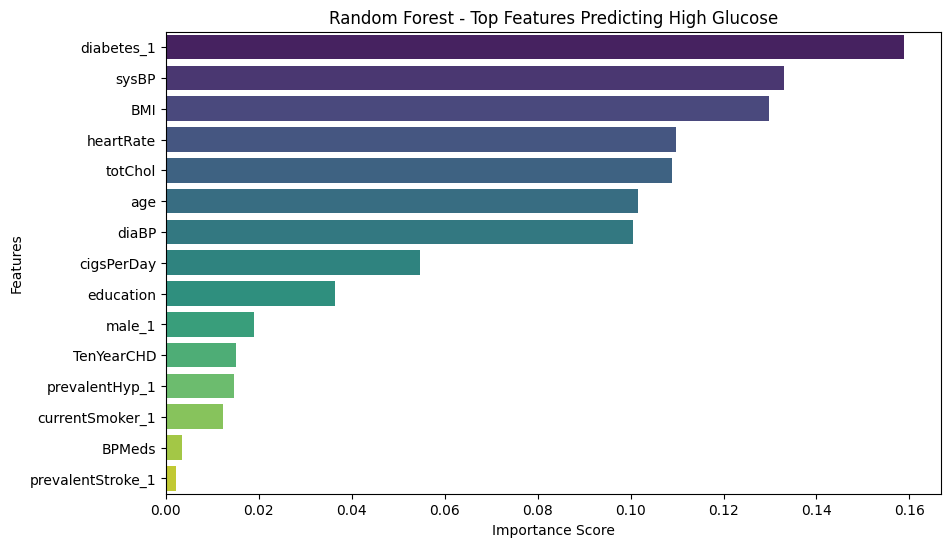

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances from your winning Random Forest model
importances = rf_class.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': X_class.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis', hue='Feature', legend=False)
plt.title('Random Forest - Top Features Predicting High Glucose')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()